# Datathon – Passos Mágicos

## Modelo Preditivo de Risco de Defasagem

Objetivo:
Desenvolver análises e um modelo preditivo capaz de identificar alunos com risco de defasagem educacional com base nos indicadores da ONG Passos Mágicos.

In [338]:
# ==============================
# ESTILO DOS GRÁFICOS
# ==============================

sns.set_theme(
    style="white"
)   

cor_principal = "#C8A2C8"
cor_secundaria = "#E7C6C7"
cor_terciaria = "#F3D8C7"
cor_quarta = "#D8B4E2"

In [339]:
# ==============================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# ==============================

import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Salvar modelo
import joblib

In [340]:
# ==============================
# 2. CARREGAMENTO DA BASE
# ==============================

arquivo = "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

xls = pd.ExcelFile(arquivo)

xls.sheet_names

['PEDE2022', 'PEDE2023', 'PEDE2024']

In [341]:
# ==============================
# 3. LEITURA DAS ABAS
# ==============================

pede_2022 = pd.read_excel(
    arquivo,
    sheet_name='PEDE2022'
)

pede_2023 = pd.read_excel(
    arquivo,
    sheet_name='PEDE2023'
)

pede_2024 = pd.read_excel(
    arquivo,
    sheet_name='PEDE2024'
)

In [342]:
# ==============================
# 4. PADRONIZAÇÃO DAS COLUNAS
# ==============================

pede_2022.columns = pede_2022.columns.str.strip()
pede_2023.columns = pede_2023.columns.str.strip()
pede_2024.columns = pede_2024.columns.str.strip()

In [343]:
# ==============================
# 5. UNIFICAÇÃO DAS BASES
# ==============================

pede_total = pd.concat(
    [
        pede_2022,
        pede_2023,
        pede_2024
    ],

    ignore_index=True
)

In [344]:
# ==============================
# 7. TRATAMENTO DOS INDICADORES
# ==============================

indicadores = [
    'IAN',
    'IDA',
    'IEG',
    'IAA',
    'IPS',
    'IPP',
    'IPV',
    'Defasagem'
]

for col in indicadores:

    pede_total[col] = pd.to_numeric(
        pede_total[col],
        errors='coerce'
    )

# arredondamento
pede_total[indicadores] = (
    pede_total[indicadores]
    .round(2)
)

In [345]:
# ==============================
# 8. ANÁLISE DE VALORES NULOS
# ==============================

pede_total[
    indicadores
].isnull().sum()

IAN             0
IDA           178
IEG            76
IAA           165
IPS           171
IPP          1038
IPV           178
Defasagem     860
dtype: int64

In [346]:
# ==============================
# 9. TRATAMENTO DE VALORES NULOS
# ==============================

pede_total = pede_total.dropna(

subset=[
    'IAN',
    'IDA',
    'IEG',
    'IAA',
    'IPS',
    'IPP',
    'IPV',
    'Defasagem'
]
)

In [347]:
# ==============================
# 10. VERIFICAÇÃO FINAL DOS DADOS
# ==============================

pede_total[
    [
         'IAN',
    'IDA',
    'IEG',
    'IAA',
    'IPS',
    'IPP',
    'IPV',
    'Defasagem'
    ]
].describe()

,IAN,IDA,IEG,IAA,IPS,IPP,IPV,Defasagem
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,7.264484,6.499814,8.376423,7.775436,6.034791,7.555814,7.672695,-0.593955
std,2.519695,1.905245,1.514357,2.810568,1.959383,0.938229,1.057618,0.829985
min,2.500000,0.000000,0.000000,0.000000,2.510000,2.500000,2.940000,-4.000000
25%,5.000000,5.250000,7.700000,7.900000,5.000000,7.080000,7.080000,-1.000000
50%,5.000000,6.750000,8.800000,8.750000,6.880000,7.500000,7.740000,-1.000000
75%,10.000000,8.000000,9.500000,9.500000,7.510000,8.120000,8.340000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.010000,3.000000


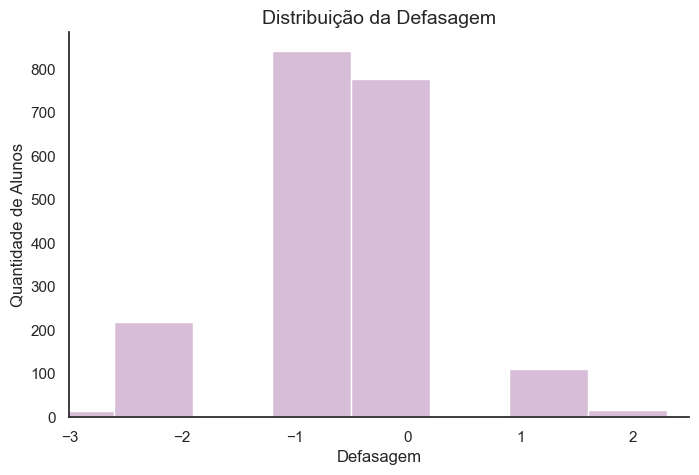


A distribuição da defasagem
demonstrou concentração dos
alunos em níveis próximos
da média educacional.

Entretanto, ainda foram
identificados grupos com
maior risco de defasagem,
reforçando a importância
de acompanhamento pedagógico
contínuo.



In [348]:
# ==============================
# 11. PERFIL GERAL DA DEFASAGEM
# ==============================

## Pergunta 1 — Perfil geral da defasagem

plt.figure(figsize=(8,5))

sns.histplot(
    pede_total['Defasagem'],

    bins=10,

    color=cor_principal,


    alpha=0.7
)

plt.title(
    'Distribuição da Defasagem',
    fontsize=14
)

plt.xlabel(
    'Defasagem'
)

plt.ylabel(
    'Quantidade de Alunos'
)

sns.despine()
plt.xlim(-3, 2.5)

plt.show()


print("""
A distribuição da defasagem
demonstrou concentração dos
alunos em níveis próximos
da média educacional.

Entretanto, ainda foram
identificados grupos com
maior risco de defasagem,
reforçando a importância
de acompanhamento pedagógico
contínuo.
""")

In [349]:
# ==============================
# 12. MÉDIA DOS INDICADORES
# ==============================

pede_total[
    [
        'IAN',
        'IDA',
        'IEG',
        'IAA',
        'IPS',
        'IPP',
        'IPV',
        'Defasagem'
    ]
].mean().sort_values()

Defasagem   -0.593955
IPS          6.034791
IDA          6.499814
IAN          7.264484
IPP          7.555814
IPV          7.672695
IAA          7.775436
IEG          8.376423
dtype: float64

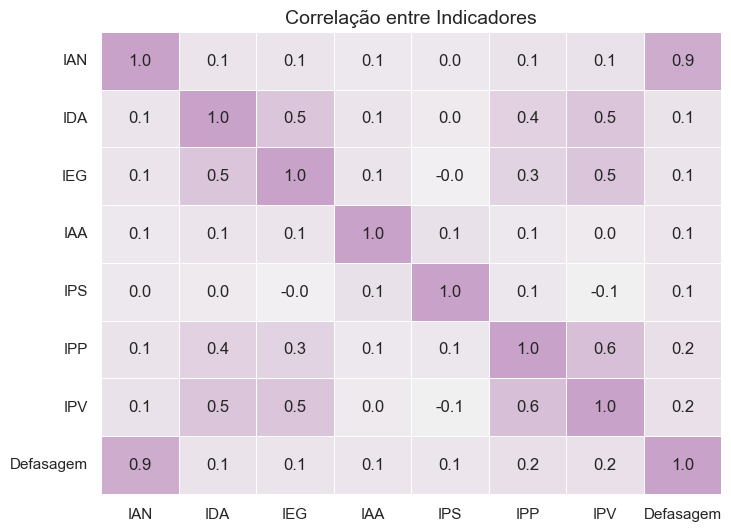


Os indicadores apresentaram
relações relevantes entre si,
evidenciando que o desempenho
dos alunos é influenciado por
múltiplas dimensões acadêmicas,
emocionais e de engajamento.

Destacou-se a forte correlação
entre IAN e Defasagem,
indicando associação significativa
entre adequação de nível e risco
de defasagem educacional.



In [350]:
# ==============================
# 13. CORRELAÇÃO ENTRE INDICADORES
# ==============================

# Pergunta 8 — Multidimensionalidade

plt.figure(figsize=(8,6))

sns.heatmap(

    pede_total[
     [
        'IAN',
        'IDA',
        'IEG',
        'IAA',
        'IPS',
        'IPP',
        'IPV',
        'Defasagem'
    ]
    ].corr(),

    annot=True,

    fmt='.1f',

    cmap=sns.light_palette(
        "#C8A2C8",
        as_cmap=True
    ),

    linewidths=0.5,

    cbar=False
)

plt.title(
    'Correlação entre Indicadores',
    fontsize=14
)

plt.xticks(rotation=0)

plt.yticks(rotation=0)

sns.despine(
    left=True,
    bottom=True
)

plt.show()


print("""
Os indicadores apresentaram
relações relevantes entre si,
evidenciando que o desempenho
dos alunos é influenciado por
múltiplas dimensões acadêmicas,
emocionais e de engajamento.

Destacou-se a forte correlação
entre IAN e Defasagem,
indicando associação significativa
entre adequação de nível e risco
de defasagem educacional.
""")

In [351]:
# ==============================
# 14. CRIAÇÃO DA VARIÁVEL ALVO
# ==============================

pede_total['risco_defasagem'] = np.where(

    pede_total['Defasagem'] < 0,

    1,

    0
)

In [352]:
# ==============================
# 15. DISTRIBUIÇÃO DO RISCO
# ==============================

pede_total[
    'risco_defasagem'
].value_counts()

risco_defasagem
1    1078
0     907
Name: count, dtype: int64

In [353]:
# ==============================
# 16. SELEÇÃO DAS FEATURES
# ==============================

features = [
    'IDA',
    'IEG',
    'IAA',
    'IPS',
    'IPP',
    'IPV'
]

X = pede_total[
    features
]

y = pede_total[
    'risco_defasagem'
]

In [354]:
# ==============================
# 17. SEPARAÇÃO TREINO E TESTE
# ==============================

X_train, X_test, y_train, y_test = (
    
    train_test_split(
        
        X,
        y,
        
        test_size=0.2,
        
        random_state=42,
        
        stratify=y
    )
)

In [355]:
## Pergunta 9 — Modelo preditivo

In [356]:
# ==============================
# 18. TREINAMENTO DO MODELO
# ==============================

modelo = (
    
    GradientBoostingClassifier(
        random_state=42
    )
)

modelo.fit(
    X_train,
    y_train
)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [357]:
# ==============================
# 19. PREVISÕES
# ==============================

pred = modelo.predict(
    X_test
)

In [358]:
# ==============================
# 20. AVALIAÇÃO DO MODELO
# ==============================

print(
    "Acurácia:",
    
    accuracy_score(
        y_test,
        pred
    )
)

Acurácia: 0.6196473551637279


In [359]:
# ==============================
# 21. RELATÓRIO DE CLASSIFICAÇÃO
# ==============================

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.61      0.47      0.53       181
           1       0.63      0.75      0.68       216

    accuracy                           0.62       397
   macro avg       0.62      0.61      0.61       397
weighted avg       0.62      0.62      0.61       397



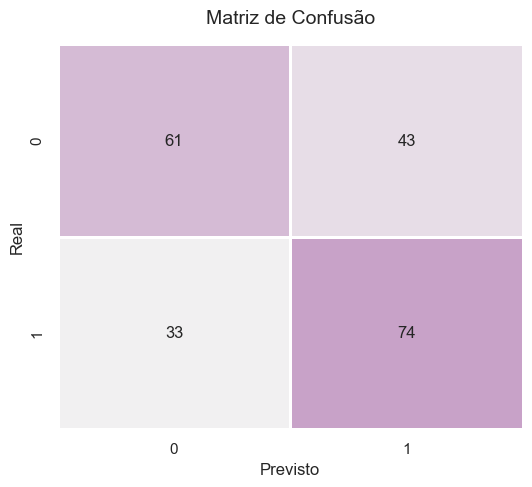

In [374]:
# ==============================
# 22. MATRIZ DE CONFUSÃO
# ==============================

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    annot_kws={"size":12},

    cmap=sns.light_palette(
        cor_principal,
        as_cmap=True
    ),

    cbar=False,

    linewidths=1,

    linecolor='white'
)

plt.title(
    'Matriz de Confusão',
    fontsize=14,
    pad=15
)

plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()


In [375]:
print("""
O modelo preditivo apresentou
capacidade moderada de identificação
de alunos em risco de defasagem.

Os resultados demonstraram que
indicadores relacionados ao
engajamento, desempenho acadêmico
e aspectos psicossociais possuem
influência relevante na previsão
do risco educacional.

Apesar das limitações inerentes
a dados educacionais, o modelo
demonstrou potencial para apoiar
ações preventivas e estratégias
pedagógicas de acompanhamento.
""")


O modelo preditivo apresentou
capacidade moderada de identificação
de alunos em risco de defasagem.

Os resultados demonstraram que
indicadores relacionados ao
engajamento, desempenho acadêmico
e aspectos psicossociais possuem
influência relevante na previsão
do risco educacional.

Apesar das limitações inerentes
a dados educacionais, o modelo
demonstrou potencial para apoiar
ações preventivas e estratégias
pedagógicas de acompanhamento.



In [376]:
# ==============================
# 23. IMPORTÂNCIA DAS FEATURES
# ==============================

importancias = pd.DataFrame({
    
    'Variavel': features,
    
    'Importancia':
    modelo.feature_importances_
})

importancias = (

    importancias.sort_values(

        by='Importancia',

        ascending=True
    )
)

importancias

,Variavel,Importancia
2,IAA,0.084019
0,IDA,0.113567
4,IPP,0.152904
3,IPS,0.183159
1,IEG,0.197137
5,IPV,0.269214


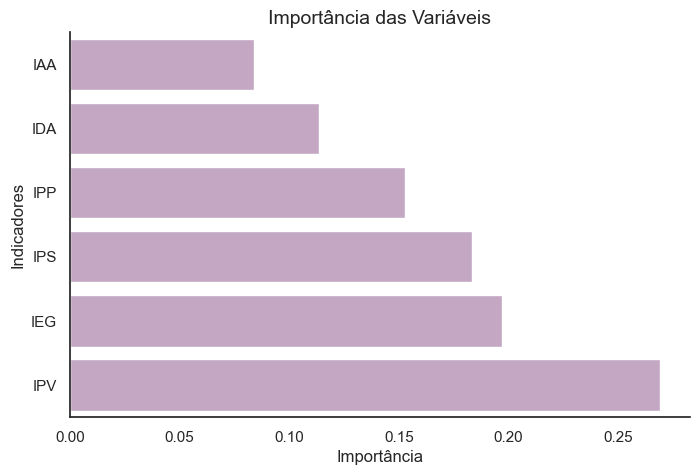


Os resultados demonstraram que
indicadores relacionados ao
engajamento, vulnerabilidade
e aspectos psicossociais
apresentaram maior influência
na previsão do risco de defasagem.

As variáveis IPV e IEG
destacaram-se como os fatores
mais relevantes para o modelo
preditivo desenvolvido.



In [377]:
# ==============================
# 24. GRÁFICO DAS IMPORTÂNCIAS
# ==============================

## Pergunta 7 — Ponto de virada (IPV)


plt.figure(figsize=(8,5))

sns.barplot(
    data=importancias,

    x='Importancia',

    y='Variavel',

    color=cor_principal
)

plt.title(
    'Importância das Variáveis',
    fontsize=14
)

plt.xlabel(
    'Importância'
)

plt.ylabel(
    'Indicadores'
)

sns.despine()

plt.show()


print("""
Os resultados demonstraram que
indicadores relacionados ao
engajamento, vulnerabilidade
e aspectos psicossociais
apresentaram maior influência
na previsão do risco de defasagem.

As variáveis IPV e IEG
destacaram-se como os fatores
mais relevantes para o modelo
preditivo desenvolvido.
""")

In [364]:
# ==============================
# 25. SALVAR MODELO
# ==============================

joblib.dump(
    modelo,
    'modelo_defasagem.pkl'
)

['modelo_defasagem.pkl']


## ANÁLISES EDUCACIONAIS — RECORTE 2024


As análises a seguir utilizam
o recorte de 2024 com o objetivo
de explorar o cenário educacional
mais recente da ONG Passos Mágicos.

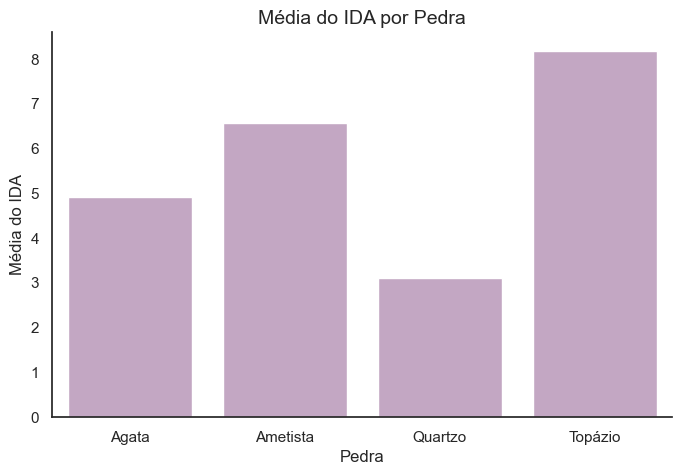


Os resultados indicaram
diferenças no desempenho
acadêmico médio entre os
níveis educacionais do programa.

As fases mais avançadas
apresentaram maiores médias
de IDA, sugerindo evolução
acadêmica ao longo da jornada
educacional dos alunos.



In [382]:
# ==============================
# 27. DESEMPENHO ACADÊMICO POR PEDRA
# ==============================

## Pergunta 2 — Desempenho acadêmico (IDA)

media_ida = (

    pede_2024[
        pede_2024['Pedra 2024'].isin(
            ['Agata', 'Ametista', 'Quartzo', 'Topázio']
        )
    ]

    .groupby('Pedra 2024')['IDA']

    .mean()
)

plt.figure(figsize=(8,5))

sns.barplot(

    x=media_ida.index,

    y=media_ida.values,

    color=cor_principal
)

plt.title(
    'Média do IDA por Pedra',
    fontsize=14
)

plt.xlabel(
    'Pedra'
)

plt.ylabel(
    'Média do IDA'
)

sns.despine()

plt.show()

print("""
Os resultados indicaram
diferenças no desempenho
acadêmico médio entre os
níveis educacionais do programa.

As fases mais avançadas
apresentaram maiores médias
de IDA, sugerindo evolução
acadêmica ao longo da jornada
educacional dos alunos.
""")

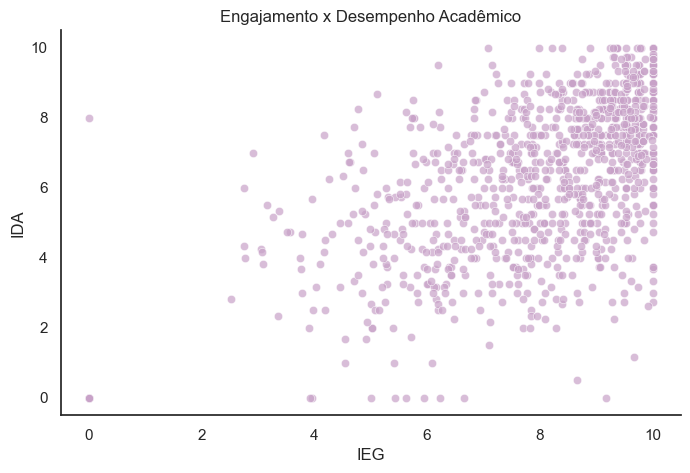


Foi observada relação positiva
entre engajamento escolar e
desempenho acadêmico.

Alunos com maiores níveis
de participação e envolvimento
nas atividades educacionais
tenderam a apresentar melhores
resultados escolares.



In [385]:
# ==============================
# 28. RELAÇÃO ENTRE IEG E IDA
# ==============================

## Pergunta 3 — Engajamento (IEG)


plt.figure(figsize=(8,5))

sns.scatterplot(
    data=pede_2024,
    x='IEG',
    y='IDA',
    color=cor_principal,
    alpha=0.7
)
plt.title(
    'Engajamento x Desempenho Acadêmico'
)

plt.xlabel(
    'IEG'
)

plt.ylabel(
    'IDA'
)
sns.despine()

plt.show()

print("""
Foi observada relação positiva
entre engajamento escolar e
desempenho acadêmico.

Alunos com maiores níveis
de participação e envolvimento
nas atividades educacionais
tenderam a apresentar melhores
resultados escolares.
""")

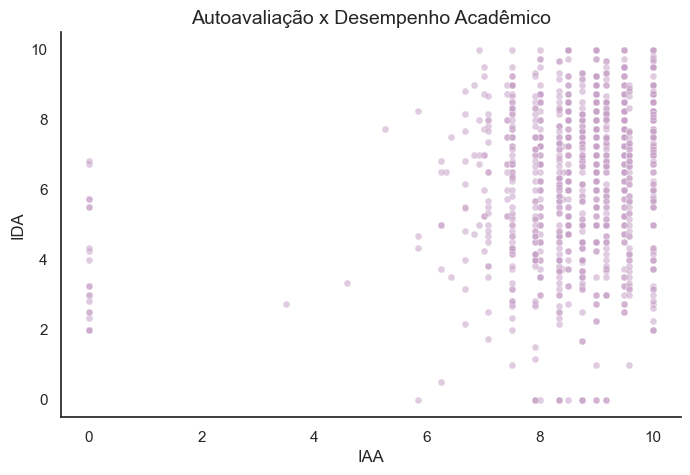


Os dados demonstraram relação
moderada entre autoavaliação
e desempenho acadêmico.

Alunos com percepção mais
positiva sobre si mesmos
tenderam a apresentar melhores
resultados escolares.



In [394]:
# ==============================
# 29. IAA X IDA
# ==============================

## Pergunta 4 — Autoavaliação (IAA)

plt.figure(figsize=(8,5))

sns.scatterplot(

    data=pede_2024,

    x='IAA',

    y='IDA',

    color=cor_principal,

    alpha=0.55,

    s=25
)

plt.title(
    'Autoavaliação x Desempenho Acadêmico',
    fontsize=14
)

plt.xlabel(
    'IAA'
)

plt.ylabel(
    'IDA'
)

sns.despine()

plt.show()

print("""
Os dados demonstraram relação
moderada entre autoavaliação
e desempenho acadêmico.

Alunos com percepção mais
positiva sobre si mesmos
tenderam a apresentar melhores
resultados escolares.
""")

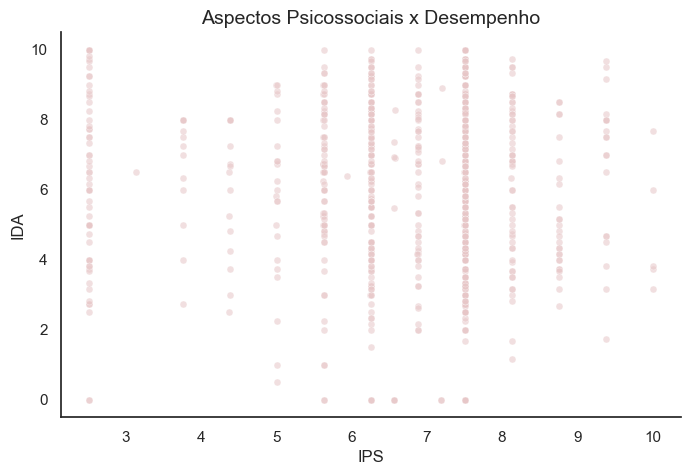


Os aspectos psicossociais
apresentaram relação moderada
com o desempenho acadêmico.

Os resultados sugerem que
fatores emocionais e sociais
podem impactar parcialmente
o desempenho escolar dos alunos.



In [396]:
# ==============================
# 30. IPS X IDA
# ==============================

## Pergunta 5 — Aspectos psicossociais (IPS)
plt.figure(figsize=(8,5))

sns.scatterplot(

    data=pede_2024,

    x='IPS',

    y='IDA',

    color=cor_secundaria,

    alpha=0.55,

    s=25
)

plt.title(
    'Aspectos Psicossociais x Desempenho',
    fontsize=14
)

plt.xlabel(
    'IPS'
)

plt.ylabel(
    'IDA'
)

sns.despine()

plt.show()

print("""
Os aspectos psicossociais
apresentaram relação moderada
com o desempenho acadêmico.

Os resultados sugerem que
fatores emocionais e sociais
podem impactar parcialmente
o desempenho escolar dos alunos.
""")

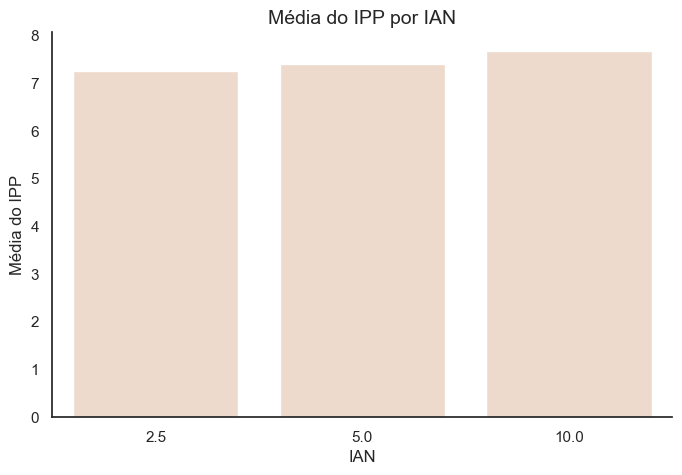


Os resultados sugerem relação
entre os níveis de adequação
educacional (IAN) e os aspectos
psicopedagógicos (IPP).

Alunos com melhores níveis
de adequação tenderam a apresentar
indicadores psicopedagógicos
ligeiramente superiores.



In [398]:
# ==============================
# 31. IPP X IAN
# ==============================

# Pergunta 6 — Aspectos psicopedagógicos (IPP)

# transforma IAN em categoria
pede_2024['IAN_cat'] = (
    pede_2024['IAN']
    .astype(str)
)

media_ipp = (

    pede_2024

    .groupby('IAN_cat')['IPP']

    .mean()
)

# ordena corretamente as categorias
media_ipp = media_ipp.reindex(
    ['2.5', '5.0', '10.0']
)

plt.figure(figsize=(8,5))

sns.barplot(

    x=media_ipp.index,

    y=media_ipp.values,

    color=cor_terciaria
)

plt.title(
    'Média do IPP por IAN',
    fontsize=14
)

plt.xlabel(
    'IAN'
)

plt.ylabel(
    'Média do IPP'
)

sns.despine()

plt.show()

print("""
Os resultados sugerem relação
entre os níveis de adequação
educacional (IAN) e os aspectos
psicopedagógicos (IPP).

Alunos com melhores níveis
de adequação tenderam a apresentar
indicadores psicopedagógicos
ligeiramente superiores.
""")

In [371]:
# ==============================
# 32. EFETIVIDADE DO PROGRAMA
# ==============================

## Pergunta 10 — Efetividade do programa

print("""
Os resultados observados ao
longo da análise sugerem
efetividade do programa
Passos Mágicos no desenvolvimento
educacional dos alunos.

Indicadores como IDA, IEG
e INDE apresentaram melhores
resultados nas pedras mais
avançadas do programa,
indicando evolução acadêmica
e comportamental ao longo
da trajetória educacional.

Além disso, os fatores de
engajamento e acompanhamento
psicopedagógico demonstraram
impacto relevante na redução
do risco de defasagem.
""")


Os resultados observados ao
longo da análise sugerem
efetividade do programa
Passos Mágicos no desenvolvimento
educacional dos alunos.

Indicadores como IDA, IEG
e INDE apresentaram melhores
resultados nas pedras mais
avançadas do programa,
indicando evolução acadêmica
e comportamental ao longo
da trajetória educacional.

Além disso, os fatores de
engajamento e acompanhamento
psicopedagógico demonstraram
impacto relevante na redução
do risco de defasagem.



In [372]:
# ==============================
# 33. CONCLUSÕES GERAIS
# ==============================

print("""
CONCLUSÕES PRINCIPAIS

1. O desempenho acadêmico
apresentou evolução conforme
o avanço nas pedras do programa.

2. Indicadores de engajamento
e aspectos psicossociais
demonstraram forte relação
com desempenho e risco de
defasagem.

3. O modelo preditivo apresentou
capacidade satisfatória na
identificação inicial de alunos
em risco educacional.

4. Os resultados reforçam
a importância do acompanhamento
acadêmico, emocional e
psicopedagógico realizado
pela ONG Passos Mágicos.
""")




CONCLUSÕES PRINCIPAIS

1. O desempenho acadêmico
apresentou evolução conforme
o avanço nas pedras do programa.

2. Indicadores de engajamento
e aspectos psicossociais
demonstraram forte relação
com desempenho e risco de
defasagem.

3. O modelo preditivo apresentou
capacidade satisfatória na
identificação inicial de alunos
em risco educacional.

4. Os resultados reforçam
a importância do acompanhamento
acadêmico, emocional e
psicopedagógico realizado
pela ONG Passos Mágicos.

